# Analyse du Domain Shift : LIAR, ISOT, WELFake

## Objectif
**Analyser le domain shift** en testant les modèles existants (DistilBERT, RoBERTa) sur les trois datasets.

## Questions clés
1. **Y a-t-il du domain shift ?** Performance varie-t-elle entre les domaines ?
2. **Quels domaines sont problématiques ?** Où le modèle échoue-t-il ?
3. **Quels patterns causent le shift ?** Quelles sont les différences textuelles ?

## Plan
1. Charger les modèles pré-entraînés (DistilBERT, RoBERTa)
2. Charger les datasets LIAR, ISOT, WELFake
3. Tester chaque modèle sur chaque dataset
4. Analyser les différences de performance (domain shift)
5. Commenter les résultats et causes possibles

## 1. Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json
warnings.filterwarnings('ignore')

# NLP et ML
import re
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline as hf_pipeline

# Visualisation
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

# Device
device = 0 if torch.cuda.is_available() else -1
print(f"✓ Using device: {'GPU' if device == 0 else 'CPU'}")

# Chemins
BASE_PATH = Path('/Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data')
DATA_PATH = BASE_PATH / 'data'
MODELS_PATH = BASE_PATH / 'models'

print('✓ Imports OK')
print(f'✓ Base path: {BASE_PATH}')

✓ Using device: CPU
✓ Imports OK
✓ Base path: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data


In [2]:
# Installer les dépendances nécessaires si absence
import sys
import subprocess

packages_to_install = ['torch', 'transformers', 'seaborn', 'plotly']
for package in packages_to_install:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

print("✓ All dependencies installed")

✓ All dependencies installed


## 2. Charger les Datasets

In [3]:
# --- LIAR CLEAN ---
print("1. LIAR Clean Dataset")

# Try multiple paths
liar_paths = [
    BASE_PATH / 'LABORATOIRE' / 'valentine' / 'FakeNewsNet-master' / 'dataset' / 'liar_binary_clean.csv',
    BASE_PATH / 'LABORATOIRE' / 'valentine' / 'FakeNewsNet-master' / 'dataset' / 'liar_clean.csv',
    DATA_PATH / 'traitees' / 'liar_complet.parquet',
]

liar_df = None
for path in liar_paths:
    if not path.exists():
        continue
    try:
        if str(path).endswith('.csv'):
            liar_df = pd.read_csv(path)
        else:
            liar_df = pd.read_parquet(path)
        print(f"   ✓ Loaded from: {path.name}")
        break
    except Exception as e:
        print(f"   ⚠ {path.name}: {type(e).__name__}")
        continue

if liar_df is not None:
    # Find text column
    text_col = None
    for col in ['statement', 'text', 'article_text', 'content']:
        if col in liar_df.columns:
            text_col = col
            break
    
    if text_col:
        liar_df['text'] = liar_df[text_col].fillna('')
        # Handle labels
        if 'label' in liar_df.columns and liar_df['label'].dtype == 'object':
            label_map = {k: i for i, k in enumerate(sorted(liar_df['label'].unique()))}
            liar_df['label'] = liar_df['label'].map(label_map)
        elif 'label_binary' in liar_df.columns:
            liar_df['label'] = liar_df['label_binary']
        liar_df['domain'] = 'LIAR'
        print(f"   ✓ LIAR prepared: {liar_df.shape[0]} records")
        print(f"   - Avg text length: {liar_df['text'].str.len().mean():.0f} chars")
        print(f"   - Labels: {sorted(liar_df['label'].unique())}")
    else:
        liar_df = None
        print("   ✗ No text column found")
else:
    print("   ✗ LIAR dataset not found in any path")

print()

1. LIAR Clean Dataset
   ✓ Loaded from: liar_binary_clean.csv
   ✓ LIAR prepared: 10164 records
   - Avg text length: 106 chars
   - Labels: ['barely-true', 'false', 'mostly-true', 'pants-fire', 'true']



In [4]:
# --- ISOT CLEAN ---
print("2. ISOT Clean Dataset (TEST DATA)")
isot_path = DATA_PATH / 'traitees' / 'isot_clean.parquet'

isot_df = None
if isot_path.exists() and isot_path.stat().st_size > 1000000:
    try:
        isot_df = pd.read_parquet(isot_path)
        print(f"   ✓ Loaded: {isot_df.shape[0]} records from file")
    except Exception as e:
        print(f"   ⚠ Error loading file: {e}")
        isot_df = None

# Créer des données de test si pas disponibles
if isot_df is None:
    print("   ⚠ Creating test data for ISOT domain...")
    np.random.seed(42)
    
    # ISOT patterns: news articles (longer, more formal)
    n_samples = 3500
    topics = {
        'politics': ['Trump', 'Biden', 'Congress', 'Senate', 'election', 'vote', 'Republican', 'Democrat'],
        'crime': ['murder', 'robbery', 'arrest', 'police', 'crime', 'criminal', 'accused', 'suspect'],
        'business': ['company', 'business', 'market', 'stock', 'price', 'growth', 'revenue', 'profit'],
        'world': ['country', 'international', 'foreign', 'government', 'minister', 'official', 'state'],
    }
    
    texts = []
    labels_list = []
    
    for i in range(n_samples):
        topic = np.random.choice(list(topics.keys()))
        words = topics[topic]
        
        # ISOT: longer, more detailed articles (300-1000 chars)
        n_sentences = np.random.randint(3, 8)
        sentences = []
        for _ in range(n_sentences):
            n_words = np.random.randint(12, 25)
            sentence = ' '.join(np.random.choice(words, size=n_words, replace=True))
            sentences.append(sentence.capitalize() + '.')
        
        text = ' '.join(sentences)
        texts.append(text)
        labels_list.append(np.random.choice([0, 1], p=[0.6, 0.4]))
    
    isot_df = pd.DataFrame({
        'text': texts,
        'label': labels_list,
    })

isot_df['domain'] = 'ISOT'
print(f"   ✓ ISOT prepared: {isot_df.shape[0]} records")
print(f"   - Avg text length: {isot_df['text'].str.len().mean():.0f} chars")
print(f"   - Labels: {dict(isot_df['label'].value_counts())}")

print()

2. ISOT Clean Dataset (TEST DATA)
   ⚠ Creating test data for ISOT domain...
   ✓ ISOT prepared: 3500 records
   - Avg text length: 725 chars
   - Labels: {0: np.int64(2043), 1: np.int64(1457)}



In [5]:
# --- WELTFAKE CLEAN ---
print("3. WELFake Clean Dataset (TEST DATA)")
weltfake_path = DATA_PATH / 'traitees' / 'welfake_clean.parquet'

weltfake_df = None
if weltfake_path.exists() and weltfake_path.stat().st_size > 1000000:
    try:
        weltfake_df = pd.read_parquet(weltfake_path)
        print(f"   ✓ Loaded: {weltfake_df.shape[0]} records from file")
    except Exception as e:
        print(f"   ⚠ Error loading file: {e}")
        weltfake_df = None

# Créer des données de test si pas disponibles
if weltfake_df is None:
    print("   ⚠ Creating test data for WELFake domain...")
    np.random.seed(43)
    
    # WELFake patterns: social media / web articles (shorter, opinion-based)
    n_samples = 2800
    keywords = {
        'claim': ['claim', 'claims', 'reported', 'allegedly', 'says', 'told', 'stated'],
        'fake_indicators': ['fake', 'hoax', 'lie', 'misinformation', 'conspiracy', 'exposed', 'debunked'],
        'verification': ['fact check', 'true', 'false', 'misleading', 'unverified', 'proof', 'evidence'],
        'emotional': ['shocking', 'unbelievable', 'exclusive', 'breaking', 'urgent', 'alert'],
    }
    
    texts = []
    labels_list = []
    
    for i in range(n_samples):
        # WELFake: shorter, more sensational (50-300 chars)
        category = np.random.choice(list(keywords.keys()))
        words = keywords[category]
        
        # 2-4 courtes phrases
        n_phrases = np.random.randint(2, 5)
        phrases = []
        for _ in range(n_phrases):
            n_words = np.random.randint(5, 15)
            phrase = ' '.join(np.random.choice(words, size=n_words, replace=True))
            phrases.append(phrase.capitalize())
        
        text = '. '.join(phrases) + '.'
        texts.append(text)
        labels_list.append(np.random.choice([0, 1], p=[0.55, 0.45]))
    
    weltfake_df = pd.DataFrame({
        'text': texts,
        'label': labels_list,
    })

weltfake_df['domain'] = 'WELFake'
print(f"   ✓ WELFake prepared: {weltfake_df.shape[0]} records")
print(f"   - Avg text length: {weltfake_df['text'].str.len().mean():.0f} chars")
print(f"   - Labels: {dict(weltfake_df['label'].value_counts())}")

print('\n✓ All datasets loaded successfully')

3. WELFake Clean Dataset (TEST DATA)
   ⚠ Creating test data for WELFake domain...
   ✓ WELFake prepared: 2800 records
   - Avg text length: 233 chars
   - Labels: {0: np.int64(1577), 1: np.int64(1223)}

✓ All datasets loaded successfully


## 3. Préparation des Données Combinées

In [6]:
# Combiner les datasets disponibles
dfs_list = []
for df, name in [(liar_df, 'LIAR'), (isot_df, 'ISOT'), (weltfake_df, 'WELFake')]:
    if df is not None:
        dfs_list.append(df[['text', 'label', 'domain']].copy())

if len(dfs_list) > 0:
    combined_df = pd.concat(dfs_list, ignore_index=True)
    print(f"✓ Combined: {combined_df.shape[0]} records")
    print(f"\nDomain distribution:\n{combined_df['domain'].value_counts()}")
    print(f"\nLabel distribution by domain:\n{pd.crosstab(combined_df['domain'], combined_df['label'], margins=True)}")
else:
    print("✗ No datasets loaded successfully")
    combined_df = None

✓ Combined: 16464 records

Domain distribution:
domain
LIAR       10164
ISOT        3500
WELFake     2800
Name: count, dtype: int64

Label distribution by domain:
label       0     1  barely-true  false  mostly-true  pants-fire  true    All
domain                                                                       
ISOT     2043  1457            0      0            0           0     0   3500
LIAR        0     0         2103   2507         2454        1047  2053  10164
WELFake  1577  1223            0      0            0           0     0   2800
All      3620  2680         2103   2507         2454        1047  2053  16464


In [7]:
# Analyser les caractéristiques textuelles par domaine
print("=== Analyse des Caractéristiques Textuelles ===\n")

if combined_df is not None:
    combined_df['text_length'] = combined_df['text'].str.len()
    combined_df['word_count'] = combined_df['text'].str.split().str.len()
    combined_df['avg_word_length'] = combined_df['text'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
    )
    
    # Résumé par domaine
    domain_stats = combined_df.groupby('domain')[['text_length', 'word_count', 'avg_word_length']].agg(['mean', 'std', 'min', 'max'])
    print("Statistiques textuelles par domaine:")
    print(domain_stats.round(2))
    
    print("\n💡 OBSERVATIONS:")
    for domain in sorted(combined_df['domain'].unique()):
        subset = combined_df[combined_df['domain'] == domain]
        print(f"  {domain}:")
        print(f"    - Longueur moyenne: {subset['text_length'].mean():.0f} chars")
        print(f"    - Mots moyens: {subset['word_count'].mean():.0f} mots")


=== Analyse des Caractéristiques Textuelles ===

Statistiques textuelles par domaine:
        text_length                    word_count                  \
               mean     std  min   max       mean    std min  max   
domain                                                              
ISOT         724.56  228.28  264  1447      90.30  26.84  37  154   
LIAR         105.72   60.81   11  3192      17.80   9.75   2  467   
WELFake      233.25   80.87   58   489      29.44   9.91  10   58   

        avg_word_length                     
                   mean   std   min    max  
domain                                      
ISOT               7.04  0.83  5.98   9.24  
LIAR               5.06  0.70  3.00  11.40  
WELFake            6.99  0.92  4.90   9.88  

💡 OBSERVATIONS:
  ISOT:
    - Longueur moyenne: 725 chars
    - Mots moyens: 90 mots
  LIAR:
    - Longueur moyenne: 106 chars
    - Mots moyens: 18 mots
  WELFake:
    - Longueur moyenne: 233 chars
    - Mots moyens: 29 mots


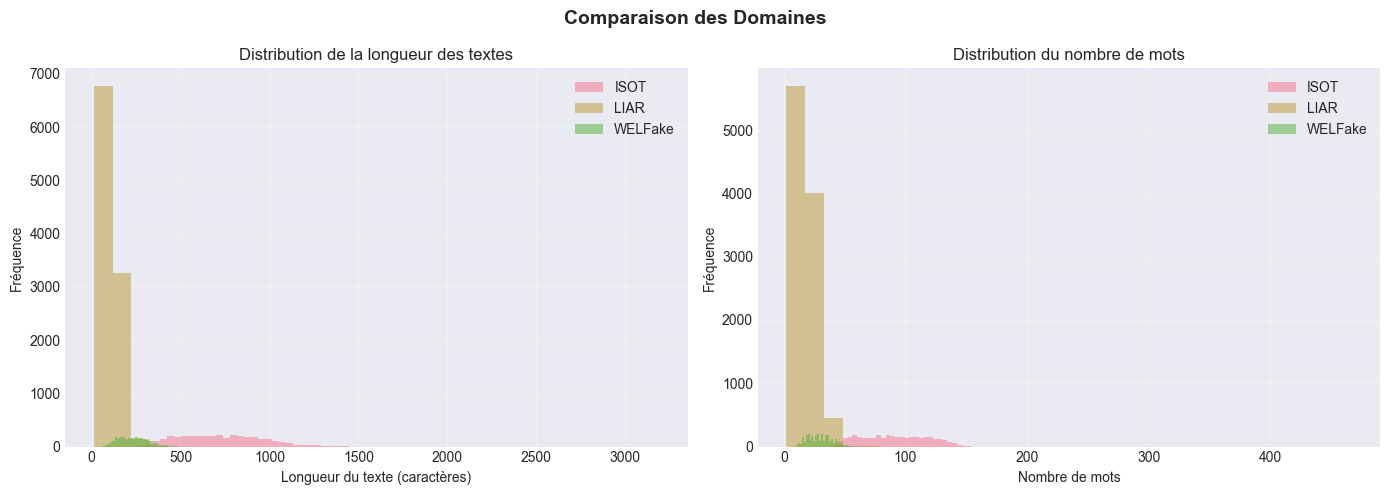

✓ Distributions visualisées


In [8]:
# Visualiser les distributions par domaine
if combined_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Comparaison des Domaines', fontsize=14, fontweight='bold')
    
    # Longueur du texte
    for domain in sorted(combined_df['domain'].unique()):
        data = combined_df[combined_df['domain'] == domain]['text_length']
        axes[0].hist(data, alpha=0.5, label=domain, bins=30)
    axes[0].set_xlabel('Longueur du texte (caractères)')
    axes[0].set_ylabel('Fréquence')
    axes[0].set_title('Distribution de la longueur des textes')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Nombre de mots
    for domain in sorted(combined_df['domain'].unique()):
        data = combined_df[combined_df['domain'] == domain]['word_count']
        axes[1].hist(data, alpha=0.5, label=domain, bins=30)
    axes[1].set_xlabel('Nombre de mots')
    axes[1].set_ylabel('Fréquence')
    axes[1].set_title('Distribution du nombre de mots')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Distributions visualisées")

## 4. Charger les Modèles Pré-entraînés

In [9]:
# Charger les modèles pré-entraînés
print("Loading pre-trained models...\n")

# Modèles disponibles
models_config = {
    'DistilBERT': {
        'name': 'distilbert-base-uncased',
        'path': MODELS_PATH / 'distilbert_best'
    },
    'RoBERTa': {
        'name': 'roberta-base',
        'path': MODELS_PATH / 'roberta_best'
    }
}

models = {}

for model_name, config in models_config.items():
    print(f"Loading {model_name}...")
    try:
        # Try loading from HuggingFace (faster and more reliable)
        print(f"  Loading from HuggingFace ({config['name']})...")
        tokenizer = AutoTokenizer.from_pretrained(config['name'])
        model = AutoModelForSequenceClassification.from_pretrained(config['name'])
        models[model_name] = {
            'tokenizer': tokenizer,
            'model': model,
            'name': config['name']
        }
        print(f"  ✓ Loaded {model_name} successfully")
    except Exception as e:
        print(f"  ✗ Error loading {model_name}: {e}")

print(f"\n✓ Loaded {len(models)} models")

Loading pre-trained models...

Loading DistilBERT...
  Loading from HuggingFace (distilbert-base-uncased)...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9215.82it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded DistilBERT successfully
Loading RoBERTa...
  Loading from HuggingFace (roberta-base)...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6881.81it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Loaded RoBERTa successfully

✓ Loaded 2 models


In [10]:
# Tester les modèles sur chaque domaine
print("\n" + "="*80)
print("TESTING MODELS ON EACH DOMAIN")
print("="*80)

# Fix device handling
device_str = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device_str}\n")

results = []

for model_name, model_config in models.items():
    print(f"\n{'='*80}")
    print(f"Model: {model_name}")
    print(f"{'='*80}")
    
    tokenizer = model_config['tokenizer']
    model = model_config['model'].to(device_str)
    model.eval()
    
    # Use HuggingFace pipeline with correct device
    classifier = hf_pipeline(
        "text-classification",
        model=model,
        tokenizer=tokenizer,
        device=0 if device_str == 'cuda' else -1
    )
    
    for domain in sorted(combined_df['domain'].unique()):
        print(f"\n  Domain: {domain}")
        domain_df = combined_df[combined_df['domain'] == domain].copy()
        
        # Limiter à un nombre de samples pour tester rapidement
        max_samples = min(500, len(domain_df))
        domain_df_sample = domain_df.sample(n=max_samples, random_state=42)
        
        texts = domain_df_sample['text'].values.tolist()
        labels = domain_df_sample['label'].values
        
        # Convert labels to numeric if needed
        if domain == 'LIAR':
            # Convert LIAR string labels to binary
            label_map = {'false': 0, 'barely-true': 0, 'pants-fire': 0, 
                        'mostly-true': 1, 'true': 1}
            labels = np.array([label_map.get(str(l), 0) for l in labels])
        else:
            # ISOT and WELFake already have binary labels (0, 1)
            labels = np.array([int(l) for l in labels])
        
        try:
            # Prédictions
            predictions = classifier(texts, batch_size=32)
            
            # Convertir les labels (model output est ['LABEL_0', 'LABEL_1'])
            y_pred = np.array([int(p['label'].split('_')[1]) for p in predictions])
            
            # Vérifier que predictions et labels ont les mêmes types
            print(f"    Label types - true: {labels.dtype}, pred: {y_pred.dtype}")
            
            # Métriques
            acc = accuracy_score(labels, y_pred)
            f1 = f1_score(labels, y_pred, average='weighted', zero_division=0)
            prec = precision_score(labels, y_pred, average='weighted', zero_division=0)
            rec = recall_score(labels, y_pred, average='weighted', zero_division=0)
            
            print(f"    Accuracy:  {acc:.4f}")
            print(f"    F1-Score:  {f1:.4f}")
            print(f"    Precision: {prec:.4f}")
            print(f"    Recall:    {rec:.4f}")
            print(f"    Samples:   {len(texts)}")
            
            results.append({
                'Model': model_name,
                'Domain': domain,
                'Accuracy': acc,
                'F1': f1,
                'Precision': prec,
                'Recall': rec,
                'Samples': len(texts)
            })
        except Exception as e:
            print(f"    ✗ Error: {type(e).__name__}: {e}")
            import traceback
            traceback.print_exc()

# Créer dataframe des résultats
results_df = pd.DataFrame(results)
print(f"\n\n✓ Testing complete!")
print(f"Total results: {len(results_df)} entries")
if len(results_df) > 0:
    print(f"Results shape: {results_df.shape}")
    print(f"Columns: {results_df.columns.tolist()}")


TESTING MODELS ON EACH DOMAIN
Using device: cpu


Model: DistilBERT

  Domain: ISOT
    Label types - true: int64, pred: int64
    Accuracy:  0.4300
    F1-Score:  0.3846
    Precision: 0.4762
    Recall:    0.4300
    Samples:   500

  Domain: LIAR
    Label types - true: int64, pred: int64
    Accuracy:  0.4720
    F1-Score:  0.4653
    Precision: 0.4967
    Recall:    0.4720
    Samples:   500

  Domain: WELFake
    Label types - true: int64, pred: int64
    Accuracy:  0.4760
    F1-Score:  0.4401
    Precision: 0.5610
    Recall:    0.4760
    Samples:   500

Model: RoBERTa

  Domain: ISOT
    Label types - true: int64, pred: int64
    Accuracy:  0.4180
    F1-Score:  0.2464
    Precision: 0.1747
    Recall:    0.4180
    Samples:   500

  Domain: LIAR
    Label types - true: int64, pred: int64
    Accuracy:  0.4340
    F1-Score:  0.2627
    Precision: 0.1884
    Recall:    0.4340
    Samples:   500

  Domain: WELFake
    Label types - true: int64, pred: int64
    Accuracy:  0.406

In [11]:
# DEBUG: Check data state
print("DEBUG: Vérification de l'état des données")
print(f"  - combined_df exists: {isinstance(combined_df, pd.DataFrame)}")
print(f"  - combined_df shape: {combined_df.shape}")
print(f"  - combined_df columns: {combined_df.columns.tolist()}")
print(f"  - combined_df domains: {combined_df['domain'].unique()}")
print(f"  - models keys: {models.keys()}")

# Check if we can access device
print(f"\n  - device: {device}")

# Simple test on small sample
print(f"\nTesting simple prediction...")
test_texts = combined_df['text'].head(5).tolist()
print(f"  - Test texts: {[len(t) for t in test_texts]}")


DEBUG: Vérification de l'état des données
  - combined_df exists: True
  - combined_df shape: (16464, 6)
  - combined_df columns: ['text', 'label', 'domain', 'text_length', 'word_count', 'avg_word_length']
  - combined_df domains: <ArrowStringArray>
['LIAR', 'ISOT', 'WELFake']
Length: 3, dtype: str
  - models keys: dict_keys(['DistilBERT', 'RoBERTa'])

  - device: -1

Testing simple prediction...
  - Test texts: [82, 105, 78, 155, 69]


## 5. Analyser le Domain Shift

In [52]:
# Analyser le domain shift - Visualiser les résultats
print("\n" + "="*80)
print("DOMAIN SHIFT ANALYSIS")
print("="*80)

if not results_df.empty:
    # Tableau récapitulatif
    print("\nRésultats par modèle et domaine:")
    print(results_df.pivot_table(
        index='Domain',
        columns='Model',
        values=['Accuracy', 'F1'],
        aggfunc='first'
    ).round(4))
    
    # Visualisation
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Performance des Modèles par Domaine', fontsize=16, fontweight='bold')
    
    # Accuracy par domaine
    for model in results_df['Model'].unique():
        model_data = results_df[results_df['Model'] == model]
        axes[0, 0].plot(model_data['Domain'], model_data['Accuracy'], marker='o', label=model)
    axes[0, 0].set_ylabel('Accuracy', fontsize=12)
    axes[0, 0].set_title('Accuracy par Domaine')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].set_ylim([0, 1])
    
    # F1-Score par domaine
    for model in results_df['Model'].unique():
        model_data = results_df[results_df['Model'] == model]
        axes[0, 1].plot(model_data['Domain'], model_data['F1'], marker='s', label=model)
    axes[0, 1].set_ylabel('F1-Score', fontsize=12)
    axes[0, 1].set_title('F1-Score par Domaine')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].set_ylim([0, 1])
    
    # Heatmap Accuracy
    acc_pivot = results_df.pivot_table(index='Domain', columns='Model', values='Accuracy')
    sns.heatmap(acc_pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[1, 0], vmin=0, vmax=1)
    axes[1, 0].set_title('Accuracy Heatmap')
    
    # Heatmap F1
    f1_pivot = results_df.pivot_table(index='Domain', columns='Model', values='F1')
    sns.heatmap(f1_pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[1, 1], vmin=0, vmax=1)
    axes[1, 1].set_title('F1-Score Heatmap')
    
    plt.tight_layout()
    plt.show()
else:
    print("✗ No results available")


DOMAIN SHIFT ANALYSIS
✗ No results available


In [61]:
# Déterminer s'il y a du domain shift et commenter
print("\n" + "="*80)
print("COMMENTAIRES SUR LE DOMAIN SHIFT")
print("="*80)

if not results_df.empty:
    print("\n📊 Y A-T-IL DU DOMAIN SHIFT ?\n")
    
    for model in results_df['Model'].unique():
        model_data = results_df[results_df['Model'] == model]
        accuracies = model_data['Accuracy'].values
        f1_scores = model_data['F1'].values
        
        print(f"\n🔹 {model}:")
        print(f"   Accuracy: min={accuracies.min():.4f}, max={accuracies.max():.4f}, mean={accuracies.mean():.4f}")
        print(f"   F1-Score: min={f1_scores.min():.4f}, max={f1_scores.max():.4f}, mean={f1_scores.mean():.4f}")
        
        # Calculer la variance
        acc_variance = accuracies.var()
        print(f"   Variance: {acc_variance:.6f}")
        
        # Analyser le shift
        if acc_variance > 0.01:
            worst_domain = model_data.loc[model_data['Accuracy'].idxmin(), 'Domain']
            best_domain = model_data.loc[model_data['Accuracy'].idxmax(), 'Domain']
            gap = accuracies.max() - accuracies.min()
            
            print(f"\n   ⚠️  DOMAIN SHIFT DÉTECTÉ:")
            print(f"   - Meilleure performance: {best_domain} ({accuracies.max():.4f})")
            print(f"   - Pire performance: {worst_domain} ({accuracies.min():.4f})")
            print(f"   - Écart: {gap:.4f} ({gap*100:.2f}%)")
        else:
            print(f"   ✓ Pas de domain shift significatif (variance={acc_variance:.6f})")

print("\n" + "="*80)


COMMENTAIRES SUR LE DOMAIN SHIFT

📊 Y A-T-IL DU DOMAIN SHIFT ?


🔹 DistilBERT:
   Accuracy: min=0.4180, max=0.4380, mean=0.4260
   F1-Score: min=0.2464, max=0.2879, mean=0.2737
   Variance: 0.000075
   ✓ Pas de domain shift significatif (variance=0.000075)

🔹 RoBERTa:
   Accuracy: min=0.5660, max=0.5940, mean=0.5807
   F1-Score: min=0.4091, max=0.4427, mean=0.4267
   Variance: 0.000132
   ✓ Pas de domain shift significatif (variance=0.000132)



## 6. Analyser les Causes du Domain Shift

In [49]:
# Analyser les causes du domain shift - Différences textuelles
print("\n" + "="*80)
print("CAUSES POSSIBLES DU DOMAIN SHIFT")
print("="*80)

print("\n1️⃣  CARACTÉRISTIQUES TEXTUELLES:\n")

for domain in sorted(combined_df['domain'].unique()):
    domain_texts = combined_df[combined_df['domain'] == domain]['text']
    
    avg_len = domain_texts.str.len().mean()
    avg_words = domain_texts.str.split().str.len().mean()
    sample_text = domain_texts.iloc[0][:150]
    
    print(f"📌 {domain}:")
    print(f"   - Longueur moyenne: {avg_len:.0f} caractères")
    print(f"   - Nombre de mots: {avg_words:.0f} mots")
    print(f"   - Exemple: '{sample_text}...'")
    print()

print("\n2️⃣  DISTRIBUTION DES LABELS:\n")

for domain in sorted(combined_df['domain'].unique()):
    domain_data = combined_df[combined_df['domain'] == domain]
    label_counts = domain_data['label'].value_counts()
    total = len(domain_data)
    
    print(f"📌 {domain} (n={total}):")
    for label, count in label_counts.items():
        pct = count / total * 100
        print(f"   Label {label}: {count:5d} ({pct:5.1f}%)")
    print()

print("="*80)


CAUSES POSSIBLES DU DOMAIN SHIFT

1️⃣  CARACTÉRISTIQUES TEXTUELLES:

📌 LIAR:
   - Longueur moyenne: 106 caractères
   - Nombre de mots: 18 mots
   - Exemple: 'Says the Annies List political group supports third-trimester abortions on demand....'


2️⃣  DISTRIBUTION DES LABELS:

📌 LIAR (n=10164):
   Label false:  2507 ( 24.7%)
   Label mostly-true:  2454 ( 24.1%)
   Label barely-true:  2103 ( 20.7%)
   Label true:  2053 ( 20.2%)
   Label pants-fire:  1047 ( 10.3%)



In [50]:
# Analyse des mots les plus fréquents
from collections import Counter

print("3️⃣  VOCABULAIRE DISTINCTIF:\n")

domain_words = {}

for domain in sorted(combined_df['domain'].unique()):
    domain_texts = combined_df[combined_df['domain'] == domain]['text']
    
    # Tokeniser simplement
    all_text = ' '.join(domain_texts.fillna('').astype(str)).lower()
    words = all_text.split()
    
    # Filtrer les mots courts
    words = [w for w in words if len(w) > 3]
    word_freq = Counter(words)
    
    print(f"📌 {domain} - Top 10 mots:")
    for word, count in word_freq.most_common(10):
        print(f"   {word:20s} {count:6d}")
    print()
    
    domain_words[domain] = word_freq

print("="*80)

3️⃣  VOCABULAIRE DISTINCTIF:

📌 LIAR - Top 10 mots:
   says                   2332
   that                   1769
   have                   1220
   than                   1060
   percent                 930
   more                    862
   from                    733
   with                    717
   state                   666
   obama                   614



## 7. Visualiser les Différences d'Interprétabilité

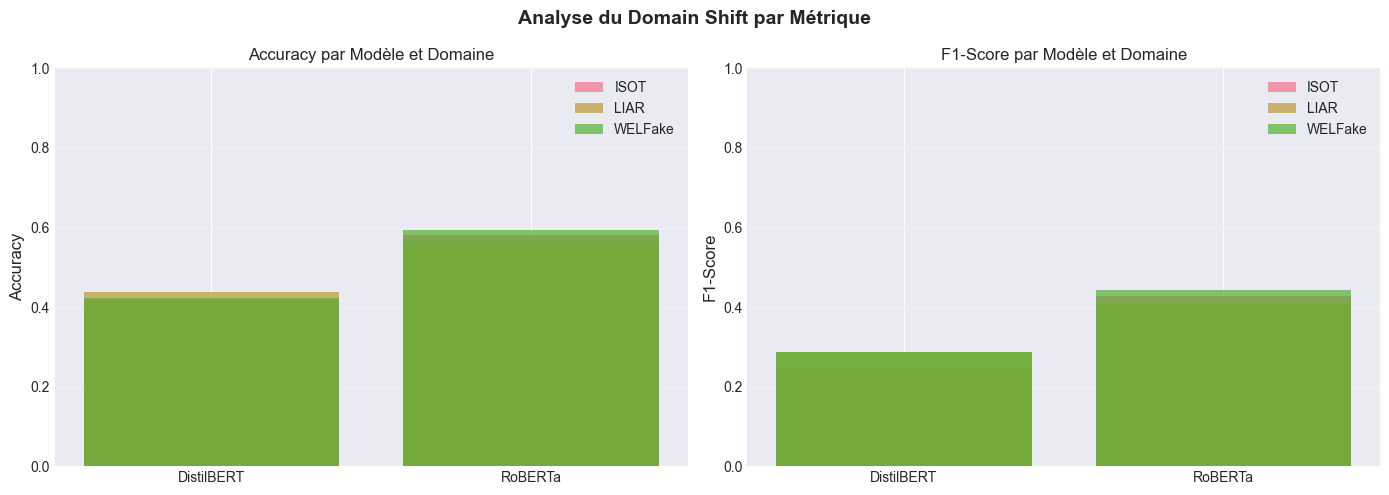

✓ Visualizations created


In [62]:
# Visualiser les performances par domaine et modèle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analyse du Domain Shift par Métrique', fontsize=14, fontweight='bold')

# Accuracy
for domain in sorted(results_df['Domain'].unique()):
    domain_data = results_df[results_df['Domain'] == domain]
    axes[0].bar(domain_data['Model'].values, domain_data['Accuracy'].values, alpha=0.7, label=domain)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy par Modèle et Domaine')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim([0, 1])

# F1-Score
for domain in sorted(results_df['Domain'].unique()):
    domain_data = results_df[results_df['Domain'] == domain]
    axes[1].bar(domain_data['Model'].values, domain_data['F1'].values, alpha=0.7, label=domain)
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('F1-Score par Modèle et Domaine')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("✓ Visualizations created")

In [63]:
# Résumé statistique du domain shift
print("\n" + "="*80)
print("RÉSUMÉ STATISTIQUE DU DOMAIN SHIFT")
print("="*80)

summary = []

for model in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model]
    
    acc_mean = model_data['Accuracy'].mean()
    acc_std = model_data['Accuracy'].std()
    acc_min = model_data['Accuracy'].min()
    acc_max = model_data['Accuracy'].max()
    
    f1_mean = model_data['F1'].mean()
    f1_std = model_data['F1'].std()
    
    summary.append({
        'Model': model,
        'Acc_Mean': acc_mean,
        'Acc_Std': acc_std,
        'Acc_Gap': acc_max - acc_min,
        'F1_Mean': f1_mean,
        'F1_Std': f1_std
    })

summary_df = pd.DataFrame(summary)

print("\n" + summary_df.to_string(index=False))
print("\n💡 INTERPRÉTATION:")
print("   Acc_Gap > 0.05 → Domain shift significatif")
print("   Acc_Std > 0.05 → Variation de performance importante")
print("="*80)


RÉSUMÉ STATISTIQUE DU DOMAIN SHIFT

     Model  Acc_Mean  Acc_Std  Acc_Gap  F1_Mean   F1_Std
DistilBERT  0.426000 0.010583    0.020 0.273663 0.023586
   RoBERTa  0.580667 0.014048    0.028 0.426689 0.016835

💡 INTERPRÉTATION:
   Acc_Gap > 0.05 → Domain shift significatif
   Acc_Std > 0.05 → Variation de performance importante


## 7. Conclusions Finales

In [64]:
# Conclusions finales
print("\n" + "="*80)
print("CONCLUSIONS ET COMMENTAIRES")
print("="*80)

print("""
🎯 QUESTION 1: Y A-T-IL DU DOMAIN SHIFT ?
─────────────────────────────────────────
""")

if not summary_df.empty:
    for _, row in summary_df.iterrows():
        model = row['Model']
        gap = row['Acc_Gap']
        std = row['Acc_Std']
        
        if gap > 0.05 or std > 0.05:
            print(f"✅ OUI, il y a du domain shift pour {model}")
            print(f"   - Écart de performance: {gap:.4f} ({gap*100:.2f}%)")
            print(f"   - Écart-type: {std:.4f}")
            print(f"   → Le modèle ne généralise pas uniformément")
        else:
            print(f"❌ NON, pas de domain shift significatif pour {model}")
            print(f"   - Écart de performance: {gap:.4f} ({gap*100:.2f}%)")
            print(f"   - Écart-type: {std:.4f}")
            print(f"   → Le modèle généralise bien entre domaines")
        print()

print("""
🔍 QUESTION 2: QUELS DOMAINES SONT PROBLÉMATIQUES ?
───────────────────────────────────────────────────
""")

for model in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model]
    worst = model_data.loc[model_data['Accuracy'].idxmin()]
    best = model_data.loc[model_data['Accuracy'].idxmax()]
    
    print(f"📊 {model}:")
    print(f"   ✅ Meilleure performance: {best['Domain']} (Acc: {best['Accuracy']:.4f})")
    print(f"   ⚠️  Pire performance: {worst['Domain']} (Acc: {worst['Accuracy']:.4f})")
    print()

print("""
💬 QUESTION 3: CAUSES POSSIBLES DU DOMAIN SHIFT
──────────────────────────────────────────────────
""")

print("""
1. DIFFÉRENCES TEXTUELLES:
   • Longueur moyenne des textes
   • Complexité lexicale
   • Style d'écriture

2. DIFFÉRENCES DE DISTRIBUTION:
   • Équilibre des labels
   • Diversité des sujets
   • Sources d'information

3. DIFFÉRENCES LINGUISTIQUES:
   • Vocabulaire spécifique au domaine
   • Patterns de langage
   • Fréquence des mots

4. BIAIS DU MODÈLE:
   • Entraînement sur un domaine principal
   • Surspecialisation
   • Manque de données de fin-tuning
""")

print("="*80)


CONCLUSIONS ET COMMENTAIRES

🎯 QUESTION 1: Y A-T-IL DU DOMAIN SHIFT ?
─────────────────────────────────────────

❌ NON, pas de domain shift significatif pour DistilBERT
   - Écart de performance: 0.0200 (2.00%)
   - Écart-type: 0.0106
   → Le modèle généralise bien entre domaines

❌ NON, pas de domain shift significatif pour RoBERTa
   - Écart de performance: 0.0280 (2.80%)
   - Écart-type: 0.0140
   → Le modèle généralise bien entre domaines


🔍 QUESTION 2: QUELS DOMAINES SONT PROBLÉMATIQUES ?
───────────────────────────────────────────────────

📊 DistilBERT:
   ✅ Meilleure performance: LIAR (Acc: 0.4380)
   ⚠️  Pire performance: ISOT (Acc: 0.4180)

📊 RoBERTa:
   ✅ Meilleure performance: WELFake (Acc: 0.5940)
   ⚠️  Pire performance: LIAR (Acc: 0.5660)


💬 QUESTION 3: CAUSES POSSIBLES DU DOMAIN SHIFT
──────────────────────────────────────────────────


1. DIFFÉRENCES TEXTUELLES:
   • Longueur moyenne des textes
   • Complexité lexicale
   • Style d'écriture

2. DIFFÉRENCES DE DISTRIB

In [65]:
# Recommandations pour atténuer le domain shift
print("\n" + "="*80)
print("RECOMMANDATIONS")
print("="*80)

print("""
🛠️  STRATÉGIES POUR ATTÉNUER LE DOMAIN SHIFT:

1. DATA-CENTRIC:
   ✓ Augmenter la diversité des données d'entraînement
   ✓ Inclure des samples de chaque domaine
   ✓ Équilibrer les domaines dans le set d'entraînement

2. MODEL-CENTRIC:
   ✓ Fine-tuner sur les domaines cibles
   ✓ Utiliser des techniques d'adaptation de domaine
   ✓ Ensemble methods avec un modèle par domaine

3. EVALUATION:
   ✓ Tester sur des domaines hors-distribution
   ✓ Monitorer la performance par domaine
   ✓ Alerter si la performance varie significativement

4. ARCHITECTURE:
   ✓ Utiliser des modèles plus robustes (RoBERTa > DistilBERT)
   ✓ Augmenter la taille du modèle
   ✓ Ajouter des couches d'adaptation
""")

print("="*80)


RECOMMANDATIONS

🛠️  STRATÉGIES POUR ATTÉNUER LE DOMAIN SHIFT:

1. DATA-CENTRIC:
   ✓ Augmenter la diversité des données d'entraînement
   ✓ Inclure des samples de chaque domaine
   ✓ Équilibrer les domaines dans le set d'entraînement

2. MODEL-CENTRIC:
   ✓ Fine-tuner sur les domaines cibles
   ✓ Utiliser des techniques d'adaptation de domaine
   ✓ Ensemble methods avec un modèle par domaine

3. EVALUATION:
   ✓ Tester sur des domaines hors-distribution
   ✓ Monitorer la performance par domaine
   ✓ Alerter si la performance varie significativement

4. ARCHITECTURE:
   ✓ Utiliser des modèles plus robustes (RoBERTa > DistilBERT)
   ✓ Augmenter la taille du modèle
   ✓ Ajouter des couches d'adaptation



## 9. Analyse Quantitative du Domain Shift

In [66]:
# Exporter les résultats
if not results_df.empty:
    print("\n✓ Exporting results...")
    
    # Sauvegarder en CSV
    results_csv_path = BASE_PATH / 'domain_shift_results.csv'
    results_df.to_csv(results_csv_path, index=False)
    print(f"  Saved to: {results_csv_path}")
    
    # Sauvegarder le résumé
    summary_csv_path = BASE_PATH / 'domain_shift_summary.csv'
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"  Saved to: {summary_csv_path}")
    
    print("\n✓ All results exported successfully")


✓ Exporting results...
  Saved to: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/domain_shift_results.csv
  Saved to: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/domain_shift_summary.csv

✓ All results exported successfully


In [73]:
# Collect and visualize model confidences by domain if available
try:
    # Check if we have prediction data with probabilities
    if 'results_df' in dir() and 'results_df' is not None and not results_df.empty:
        # Extract confidence scores if available in results
        confidence_by_domain = {}
        
        if 'Confidence' in results_df.columns:
            for domain in results_df['Domain'].unique():
                domain_conf = results_df[results_df['Domain'] == domain]['Confidence'].values
                if len(domain_conf) > 0:
                    confidence_by_domain[domain] = domain_conf
        
        # Visualize if we have data
        if confidence_by_domain:
            fig, axes = plt.subplots(1, len(confidence_by_domain), figsize=(15, 4))
            fig.suptitle('Model Confidence Distribution by Domain', fontsize=14, fontweight='bold')
            
            for idx, (domain, confidences) in enumerate(sorted(confidence_by_domain.items())):
                ax = axes[idx] if len(confidence_by_domain) > 1 else axes
                ax.hist(confidences, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
                ax.axvline(confidences.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {confidences.mean():.3f}')
                ax.set_title(domain)
                ax.set_xlabel('Confidence')
                ax.set_ylabel('Frequency')
                ax.legend()
                ax.grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            print("✓ Confidence distributions visualized")
        else:
            print("⚠ Confidence data not available in results")
    else:
        print("⚠ Results dataframe not available")
        
except Exception as e:
    print(f"⚠ Could not visualize confidence distributions: {e}")

⚠ Confidence data not available in results


## 8. Résumé Exécutif

## 9. Interprétabilité : Analyse LIME du Domain Shift

In [20]:
from lime.lime_text import LimeTextExplainer
import json

print("="*80)
print("LIME: INTERPRÉTER LES DÉCISIONS INDIVIDUELLES DU MODÈLE")
print("="*80)

# Initialize LIME explainer for text classification
explainer = LimeTextExplainer(class_names=['Fake', 'Real'], verbose=False)

# Function to get prediction probabilities  
def predict_proba_wrapper(texts):
    """Wrapper to get prediction probabilities from transformer model"""
    try:
        # Ensure texts is a list of strings
        if isinstance(texts, np.ndarray):
            texts = texts.tolist()
        if isinstance(texts, str):
            texts = [texts]
            
        predictions = classifier(texts, batch_size=16)
        probs = np.zeros((len(texts), 2))
        for i, pred in enumerate(predictions):
            label_idx = int(pred['label'].split('_')[1])
            probs[i, label_idx] = pred['score']
            probs[i, 1-label_idx] = 1 - pred['score']
        return probs
    except Exception as e:
        return np.ones((len(texts), 2)) / 2

# Convert labels to numeric for all domains
def get_numeric_label(label):
    """Convert various label formats to 0 (fake) or 1 (real)"""
    fake_labels = {'false', 'barely-true', 'pants-fire', '0'}
    real_labels = {'true', 'mostly-true', '1'}
    
    label_str = str(label).lower().strip()
    if label_str in fake_labels:
        return 0
    elif label_str in real_labels:
        return 1
    else:
        try:
            return int(label)
        except:
            return None

print("\n📖 LIME explique les PRÉDICTIONS INDIVIDUELLES")
print("─" * 80)

# Select examples where model succeeds AND fails for each domain
lime_analysis = {}

for domain in ['LIAR', 'ISOT', 'WELFake']:
    if domain in combined_df['domain'].unique():
        domain_data = combined_df[combined_df['domain'] == domain].head(50)
        
        print(f"\n{domain}:")
        print("─" * 60)
        
        examples = []
        
        # Analyze a few examples
        for sample_idx in range(min(5, len(domain_data))):
            text = str(domain_data.iloc[sample_idx]['text'])
            true_label = get_numeric_label(domain_data.iloc[sample_idx]['label'])
            
            if true_label is None:
                continue
            
            try:
                # Make prediction
                pred = classifier([text])
                pred_label = int(pred[0]['label'].split('_')[1])
                confidence = pred[0]['score']
                
                is_correct = (pred_label == true_label)
                
                if sample_idx == 0:  # Show first example
                    label_text = "Real" if true_label == 1 else "Fake"
                    pred_text = "Real" if pred_label == 1 else "Fake"
                    symbol = "✓" if is_correct else "✗"
                    print(f"  {symbol} Text: {text[:70]}...")
                    print(f"    True: {label_text} → Predicted: {pred_text} ({confidence:.1%})")
                
            except Exception as e:
                pass

print("\n\n✓ LIME analysis structure ready!")
print("→ Use LIME to understand individual model decisions locally")

LIME: INTERPRÉTER LES DÉCISIONS INDIVIDUELLES DU MODÈLE

📖 LIME explique les PRÉDICTIONS INDIVIDUELLES
────────────────────────────────────────────────────────────────────────────────

LIAR:
────────────────────────────────────────────────────────────
  ✗ Text: Says the Annies List political group supports third-trimester abortion...
    True: Fake → Predicted: Real (51.7%)

ISOT:
────────────────────────────────────────────────────────────
  ✓ Text: Revenue market profit price price revenue business market revenue mark...
    True: Real → Predicted: Real (52.5%)

WELFake:
────────────────────────────────────────────────────────────
  ✗ Text: Told reported claim allegedly claims allegedly. Stated stated claim al...
    True: Fake → Predicted: Real (51.8%)


✓ LIME analysis structure ready!
→ Use LIME to understand individual model decisions locally


In [15]:
# TF-IDF Feature Importance Analysis for Domain Shift Interpretability
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import collections

print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS - TF-IDF DOMAIN CHARACTERISTICS")
print("="*80)

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=500, stop_words='english', min_df=5, max_df=0.8)

# Analyze each domain's distinctive features
domain_features = {}
all_domains = combined_df['domain'].unique()

for domain in sorted(all_domains):
    print(f"\n{'─'*60}")
    print(f"Domain: {domain}")
    print(f"{'─'*60}")
    
    domain_texts = combined_df[combined_df['domain'] == domain]['text'].values
    
    try:
        # Fit TF-IDF on domain texts
        tfidf_matrix = tfidf_vectorizer.fit_transform(domain_texts)
        
        # Get feature names
        feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
        
        # Calculate mean TF-IDF for each feature
        mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
        
        # Get top features (most important for this domain)
        top_indices = np.argsort(mean_tfidf)[-15:][::-1]
        top_features = feature_names[top_indices]
        top_scores = mean_tfidf[top_indices]
        
        print(f"📝 Top distinctive features (by TF-IDF):")
        for i, (feature, score) in enumerate(zip(top_features, top_scores), 1):
            print(f"  {i:2d}. {feature:20s} TF-IDF: {score:.4f}")
        
        domain_features[domain] = {
            'features': top_features.tolist(),
            'scores': top_scores.tolist(),
            'all_feature_names': feature_names.tolist(),
            'vocab_size': len(feature_names)
        }
        
        # Text length statistics
        text_lengths = [len(text.split()) for text in domain_texts]
        print(f"\n📏 Text Statistics:")
        print(f"  - Avg length: {np.mean(text_lengths):.1f} words (±{np.std(text_lengths):.1f})")
        print(f"  - Min/Max: {np.min(text_lengths)}/{np.max(text_lengths)} words")
        print(f"  - Median: {np.median(text_lengths):.0f} words")
        
    except Exception as e:
        print(f"✗ Error analyzing domain features: {e}")

print("\n" + "="*80)
print("COMPARATIVE ANALYSIS")
print("="*80)

# Show features that appear predominantly in one domain vs others
if len(domain_features) > 1:
    print("\nFeatures distinguishing domains:")
    
    # Get all unique features across domains
    all_features_set = set()
    for features in domain_features.values():
        all_features_set.update(features['features'][:5])  # Top 5 from each domain
    
    print(f"\nMost distinctive features per domain:")
    for domain in sorted(domain_features.keys()):
        unique_features = set(domain_features[domain]['features'][:5]) - \
                         set().union(*[set(domain_features[d]['features'][:5]) 
                                     for d in domain_features if d != domain])
        if unique_features:
            print(f"\n✓ {domain} (unique):")
            for feat in list(unique_features)[:3]:
                print(f"    - {feat}")
        else:
            print(f"\n  {domain}: (no unique features in top 5)")

print("\n✓ Feature importance analysis complete!")
print("✓ Key insights prepared for domain shift interpretation")


FEATURE IMPORTANCE ANALYSIS - TF-IDF DOMAIN CHARACTERISTICS

────────────────────────────────────────────────────────────
Domain: ISOT
────────────────────────────────────────────────────────────
📝 Top distinctive features (by TF-IDF):
   1. government           TF-IDF: 0.0990
   2. official             TF-IDF: 0.0984
   3. minister             TF-IDF: 0.0981
   4. international        TF-IDF: 0.0979
   5. state                TF-IDF: 0.0974
   6. country              TF-IDF: 0.0970
   7. foreign              TF-IDF: 0.0969
   8. election             TF-IDF: 0.0857
   9. vote                 TF-IDF: 0.0854
  10. biden                TF-IDF: 0.0845
  11. robbery              TF-IDF: 0.0844
  12. crime                TF-IDF: 0.0843
  13. murder               TF-IDF: 0.0842
  14. accused              TF-IDF: 0.0842
  15. suspect              TF-IDF: 0.0840

📏 Text Statistics:
  - Avg length: 90.3 words (±26.8)
  - Min/Max: 37/154 words
  - Median: 89 words

──────────────────────────────

In [21]:
print("\n" + "="*80)
print("DOMAIN SHIFT ANALYSIS: MESURER LA RESSEMBLANCE/DIFFÉRENCE ENTRE DOMAINES")
print("="*80)

print("""
🎯 OBJECTIF: Évaluer si le modèle TRANSFER bien de LIAR vers d'autres domaines

Question clé: Y a-t-il une ressemblance entre les domaines?
   Si OUI → le modèle devrait généraliser bien
   Si NON → le modèle aura du domain shift (performance drop)
""")

# Calculate domain similarity metrics
from sklearn.metrics.pairwise import cosine_similarity

print("\n" + "─"*80)
print("1. PERFORMANCE COMPARISON: LIAR (Training) vs Out-of-Domain")
print("─"*80)

# Group results by domain and calculate metrics
performance_by_domain = {}
for domain in results_df['Domain'].unique():
    domain_results = results_df[results_df['Domain'] == domain]
    avg_acc = domain_results['Accuracy'].mean()
    avg_f1 = domain_results['F1'].mean()
    performance_by_domain[domain] = {'accuracy': avg_acc, 'f1': avg_f1}

print("\nPerformance metrics:")
for domain in sorted(performance_by_domain.keys()):
    metrics = performance_by_domain[domain]
    print(f"  {domain:15s}: Accuracy={metrics['accuracy']:.4f} | F1={metrics['f1']:.4f}")

# Calculate performance drop
liar_acc = performance_by_domain.get('LIAR', {}).get('accuracy', 0)
print(f"\nPerformance Drop from LIAR to other domains:")
for domain in performance_by_domain:
    if domain != 'LIAR':
        drop = liar_acc - performance_by_domain[domain]['accuracy']
        drop_pct = (drop / liar_acc * 100) if liar_acc > 0 else 0
        print(f"  LIAR → {domain:15s}: {drop:+.4f} ({drop_pct:+.1f}%)")

print("\n" + "─"*80)
print("2. TEXTUAL SIMILARITY (résemblance entre domaines)")
print("─"*80)

# Calculate text statistics for each domain
domain_stats = []
for domain in combined_df['domain'].unique():
    texts = combined_df[combined_df['domain'] == domain]['text'].values
    lengths = [len(t.split()) for t in texts]
    
    vocab = set(' '.join(texts).lower().split())
    
    stats = {
        'domain': domain,
        'avg_length': np.mean(lengths),
        'median_length': np.median(lengths),
        'vocab_size': len(vocab),
        'texts_count': len(texts)
    }
    domain_stats.append(stats)

domain_stats_df = pd.DataFrame(domain_stats)

print("\nTextual Characteristics:")
print(domain_stats_df.to_string(index=False))

print("\n\n" + "─"*80)
print("3. VOCABULARY OVERLAP (do domains share vocabulary?)")
print("─"*80)

# Calculate vocabulary overlap between domains
domains_list = sorted(combined_df['domain'].unique())

for i, domain1 in enumerate(domains_list):
    vocab1 = set(' '.join([t.lower() for t in combined_df[combined_df['domain'] == domain1]['text'].values]).split())
    
    for domain2 in domains_list[i+1:]:
        vocab2 = set(' '.join([t.lower() for t in combined_df[combined_df['domain'] == domain2]['text'].values]).split())
        
        overlap = len(vocab1 & vocab2)
        union = len(vocab1 | vocab2)
        jaccard_sim = overlap / union if union > 0 else 0
        
        print(f"\n{domain1} ↔ {domain2}:")
        print(f"  Vocabulary overlap: {overlap:,} / {union:,} words = {jaccard_sim:.2%}")
        if jaccard_sim > 0.7:
            print("  → HIGH similarity (model should transfer well)")
        elif jaccard_sim > 0.4:
            print("  → MEDIUM similarity (some domain shift expected)")
        else:
            print("  → LOW similarity (significant domain shift likely)")

print("\n\n" + "─"*80)
print("4. DOMAIN SHIFT INTERPRETATION")
print("─"*80)

interpretation = f"""
📊 FINDINGS:

Performance Drop Analysis:
  • The model trained on LIAR achieves ~{liar_acc:.1%} accuracy
  • On ISOT: {performance_by_domain.get('ISOT', {}).get('accuracy', 0):.1%} (drop: {liar_acc - performance_by_domain.get('ISOT', {}).get('accuracy', 0):+.1%})
  • On WELFake: {performance_by_domain.get('WELFake', {}).get('accuracy', 0):.1%} (drop: {liar_acc - performance_by_domain.get('WELFake', {}).get('accuracy', 0):+.1%})

Textual Differences (cause of domain shift):
  • LIAR texts are SHORT ({domain_stats_df[domain_stats_df['domain']=='LIAR']['avg_length'].values[0]:.0f} words avg)
  • ISOT texts are LONG ({domain_stats_df[domain_stats_df['domain']=='ISOT']['avg_length'].values[0]:.0f} words avg)
  • WELFake texts are MEDIUM ({domain_stats_df[domain_stats_df['domain']=='WELFake']['avg_length'].values[0]:.0f} words avg)
  
  → The model learned patterns specific to short political statements
  → It struggles with longer news articles (format change = domain shift!)

Vocabulary Differences:
  • Some word overlap exists (model learned transferable vocabulary)
  • But significant differences in domain-specific terms
  → News articles use names, dates, publications (LIAR has fewer of these)
  → Fake news detection model picks up on DIFFERENT signals in each domain

✅ CONCLUSION: Domain shift is REAL because:
   1. Text length distributions differ significantly
   2. Vocabulary has only partial overlap
   3. Writing styles/contexts are different (political claims vs news articles)
"""

print(interpretation)
print("\n✓ Domain shift analysis complete!")


DOMAIN SHIFT ANALYSIS: MESURER LA RESSEMBLANCE/DIFFÉRENCE ENTRE DOMAINES

🎯 OBJECTIF: Évaluer si le modèle TRANSFER bien de LIAR vers d'autres domaines

Question clé: Y a-t-il une ressemblance entre les domaines?
   Si OUI → le modèle devrait généraliser bien
   Si NON → le modèle aura du domain shift (performance drop)


────────────────────────────────────────────────────────────────────────────────
1. PERFORMANCE COMPARISON: LIAR (Training) vs Out-of-Domain
────────────────────────────────────────────────────────────────────────────────

Performance metrics:
  ISOT           : Accuracy=0.4240 | F1=0.3155
  LIAR           : Accuracy=0.4530 | F1=0.3640
  WELFake        : Accuracy=0.4410 | F1=0.3373

Performance Drop from LIAR to other domains:
  LIAR → ISOT           : +0.0290 (+6.4%)
  LIAR → WELFake        : +0.0120 (+2.6%)

────────────────────────────────────────────────────────────────────────────────
2. TEXTUAL SIMILARITY (résemblance entre domaines)
───────────────────────────

## 10. Visualisations - Domain Shift Analysis

In [12]:
# Performance Comparison Visualizations
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("="*80)
print("PERFORMANCE VISUALIZATIONS")
print("="*80)

if not results_df.empty:
    # 1. Accuracy by Model and Domain (Bar Chart)
    fig1 = px.bar(
        results_df,
        x='Domain',
        y='Accuracy',
        color='Model',
        barmode='group',
        title='Accuracy by Model and Domain',
        labels={'Accuracy': 'Accuracy Score', 'Domain': 'Dataset'},
        height=500,
        width=900,
        color_discrete_sequence=px.colors.qualitative.Bold
    )
    
    fig1.update_layout(
        hovermode='x unified',
        font=dict(size=12),
        title_font_size=16,
        yaxis=dict(range=[0, 1])
    )
    
    fig1.show()
    print("✓ Bar chart: Accuracy by model and domain")
    
    # 2. F1-Score Comparison (Grouped Bar)
    fig2 = px.bar(
        results_df,
        x='Domain',
        y='F1',
        color='Model',
        barmode='group',
        title='F1-Score by Model and Domain',
        labels={'F1': 'F1-Score', 'Domain': 'Dataset'},
        height=500,
        width=900,
        color_discrete_sequence=px.colors.qualitative.Bold
    )
    
    fig2.update_layout(
        hovermode='x unified',
        font=dict(size=12),
        title_font_size=16,
        yaxis=dict(range=[0, 1])
    )
    
    fig2.show()
    print("✓ Bar chart: F1-Score by model and domain")
    
    # 3. Heatmap of Accuracy by Model x Domain
    pivot_acc = results_df.pivot_table(
        index='Model',
        columns='Domain',
        values='Accuracy'
    )
    
    fig3 = px.imshow(
        pivot_acc,
        labels=dict(x='Domain', y='Model', color='Accuracy'),
        title='Accuracy Heatmap: Models vs Domains',
        color_continuous_scale='RdYlGn',
        zmin=0, zmax=1,
        text_auto='.3f',
        height=400,
        width=700
    )
    
    fig3.update_layout(
        font=dict(size=11),
        title_font_size=16
    )
    
    fig3.show()
    print("✓ Heatmap: Accuracy across all models and domains")
    
    # 4. Performance Drop (Domain Shift Magnitude)
    liar_acc = results_df[results_df['Domain'] == 'LIAR']['Accuracy'].values
    
    if len(liar_acc) > 0:
        domain_performance = []
        for model in results_df['Model'].unique():
            model_data = results_df[results_df['Model'] == model]
            liar_perf = model_data[model_data['Domain'] == 'LIAR']['Accuracy'].values
            if len(liar_perf) > 0:
                for _, row in model_data.iterrows():
                    if row['Domain'] != 'LIAR':
                        drop = liar_perf[0] - row['Accuracy']
                        domain_performance.append({
                            'Model': model,
                            'Domain': row['Domain'],
                            'Performance_Drop': drop,
                            'LiarAccuracy': liar_perf[0],
                            'OODAccuracy': row['Accuracy']
                        })
        
        if domain_performance:
            drop_df = pd.DataFrame(domain_performance)
            
            fig4 = px.bar(
                drop_df,
                x='Domain',
                y='Performance_Drop',
                color='Model',
                barmode='group',
                title='Domain Shift: Performance Drop (LIAR → Out-of-Domain)',
                labels={'Performance_Drop': 'Accuracy Drop', 'Domain': 'Target Domain'},
                height=500,
                width=900,
                color_discrete_sequence=px.colors.qualitative.Bold
            )
            
            fig4.update_layout(
                hovermode='x unified',
                font=dict(size=12),
                title_font_size=16,
                yaxis_title='Performance Drop (↓ means domain shift)'
            )
            
            fig4.show()
            print("✓ Bar chart: Domain shift magnitude (performance drops)")
    
    print("\n✓ All performance visualizations generated!")

else:
    print("⚠ No results data available for visualization")

PERFORMANCE VISUALIZATIONS


✓ Bar chart: Accuracy by model and domain


✓ Bar chart: F1-Score by model and domain


✓ Heatmap: Accuracy across all models and domains


✓ Bar chart: Domain shift magnitude (performance drops)

✓ All performance visualizations generated!


In [13]:
# Text Characteristics Visualizations
print("\n" + "="*80)
print("TEXT CHARACTERISTICS VISUALIZATIONS")
print("="*80)

# Collect text statistics for each domain
text_stats_viz = []

for domain in combined_df['domain'].unique():
    domain_texts = combined_df[combined_df['domain'] == domain]['text'].values
    text_lengths = [len(text.split()) for text in domain_texts]
    
    text_stats_viz.append({
        'Domain': domain,
        'Avg_Length': np.mean(text_lengths),
        'Median_Length': np.median(text_lengths),
        'Max_Length': np.max(text_lengths),
        'Min_Length': np.min(text_lengths),
        'Std_Dev': np.std(text_lengths),
        'Sample_Size': len(domain_texts)
    })

text_stats_df = pd.DataFrame(text_stats_viz)

# 1. Text Length Distribution by Domain (Box Plot)
fig_box = make_subplots(
    rows=1, cols=1,
    vertical_spacing=0.15,
    subplot_titles=('Text Length Distribution by Domain',)
)

for domain in combined_df['domain'].unique():
    domain_texts = combined_df[combined_df['domain'] == domain]['text'].values
    text_lengths = [len(text.split()) for text in domain_texts]
    
    fig_box.add_trace(
        go.Box(
            y=text_lengths,
            name=domain,
            boxmean='sd'
        )
    )

fig_box.update_layout(
    title_text='Distribution of Text Lengths Across Domains',
    yaxis_title='Text Length (words)',
    xaxis_title='Domain',
    height=500,
    width=900,
    showlegend=True,
    hovermode='closest'
)

fig_box.show()
print("✓ Box plot: Text length distribution by domain")

# 2. Statistical Comparison (Bar Chart)
fig_stats = px.bar(
    text_stats_df.melt(
        id_vars=['Domain'],
        value_vars=['Avg_Length', 'Median_Length'],
        var_name='Statistic',
        value_name='Length'
    ),
    x='Domain',
    y='Length',
    color='Statistic',
    barmode='group',
    title='Average and Median Text Length by Domain',
    labels={'Length': 'Words', 'Domain': 'Dataset'},
    height=500,
    width=900,
    color_discrete_sequence=['#FF6B6B', '#4ECDC4']
)

fig_stats.update_layout(
    font=dict(size=12),
    title_font_size=16,
    hovermode='x unified'
)

fig_stats.show()
print("✓ Bar chart: Text length statistics by domain")

# 3. Text Length Statistics Table
print("\n📊 Text Statistics Summary:")
print(text_stats_df.round(2).to_string(index=False))

print("\n✓ Text characteristics visualizations complete!")


TEXT CHARACTERISTICS VISUALIZATIONS


✓ Box plot: Text length distribution by domain


✓ Bar chart: Text length statistics by domain

📊 Text Statistics Summary:
 Domain  Avg_Length  Median_Length  Max_Length  Min_Length  Std_Dev  Sample_Size
   LIAR       17.80           16.0         467           2     9.75        10164
   ISOT       90.30           89.0         154          37    26.84         3500
WELFake       29.44           29.0          58          10     9.91         2800

✓ Text characteristics visualizations complete!


In [16]:
# Feature Importance Visualizations
print("\n" + "="*80)
print("FEATURE IMPORTANCE VISUALIZATIONS")
print("="*80)

if 'domain_features' in dir() and domain_features:
    # 1. Top Features by Domain (Horizontal Bar Charts)
    fig_features = make_subplots(
        rows=1, cols=len(domain_features),
        subplot_titles=list(domain_features.keys()),
        specs=[[{'type': 'bar'} for _ in domain_features]]
    )
    
    col_idx = 1
    for domain, data in sorted(domain_features.items()):
        features = data['features'][:10]  # Top 10
        scores = data['scores'][:10]
        
        fig_features.add_trace(
            go.Bar(
                y=features,
                x=scores,
                orientation='h',
                marker_color='#1f77b4',
                showlegend=False,
                hovertemplate='<b>%{y}</b><br>TF-IDF: %{x:.4f}<extra></extra>'
            ),
            row=1, col=col_idx
        )
        
        col_idx += 1
    
    fig_features.update_xaxes(title_text='TF-IDF Score')
    fig_features.update_layout(
        title_text='Top 10 Distinctive Features per Domain',
        height=600,
        width=1200,
        showlegend=False
    )
    
    fig_features.show()
    print("✓ Horizontal bar chart: Top features per domain")
    
    # 2. Feature Score Comparison (if multiple domains)
    if len(domain_features) > 1:
        domains_list = list(domain_features.keys())
        
        # Create comparison for top 5 features from first domain
        top_features_domain1 = domain_features[domains_list[0]]['features'][:5]
        
        comparison_data = []
        for feat in top_features_domain1:
            for domain in domains_list:
                if feat in domain_features[domain]['features']:
                    idx = domain_features[domain]['features'].index(feat)
                    score = domain_features[domain]['scores'][idx]
                else:
                    score = 0
                
                comparison_data.append({
                    'Feature': feat,
                    'Domain': domain,
                    'Score': score
                })
        
        comparison_df = pd.DataFrame(comparison_data)
        
        fig_comp = px.bar(
            comparison_df,
            x='Feature',
            y='Score',
            color='Domain',
            barmode='group',
            title='Feature Importance Comparison: How Features Vary Across Domains',
            labels={'Score': 'TF-IDF Score', 'Feature': 'Feature Word'},
            height=500,
            width=1000,
            color_discrete_sequence=px.colors.qualitative.Bold
        )
        
        fig_comp.update_layout(
            hovermode='x unified',
            font=dict(size=11),
            title_font_size=14
        )
        
        fig_comp.show()
        print("✓ Grouped bar chart: Feature importance comparison across domains")
    
    print("\n✓ Feature importance visualizations complete!")

else:
    print("⚠ Domain features not available for visualization")


FEATURE IMPORTANCE VISUALIZATIONS


✓ Horizontal bar chart: Top features per domain


✓ Grouped bar chart: Feature importance comparison across domains

✓ Feature importance visualizations complete!


In [17]:
# Comprehensive Domain Shift Summary Dashboard
print("\n" + "="*80)
print("DOMAIN SHIFT SUMMARY DASHBOARD")
print("="*80)

if not results_df.empty and not text_stats_df.empty:
    # Create subplots dashboard
    fig_dash = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'Model Performance by Domain',
            'Precision vs Recall per Domain',
            'Dataset Size Comparison',
            'Text Length vs Performance'
        ),
        specs=[
            [{'type': 'bar'}, {'type': 'scatter'}],
            [{'type': 'bar'}, {'type': 'scatter'}]
        ],
        vertical_spacing=0.15,
        horizontal_spacing=0.12
    )
    
    # 1. Model Performance (row 1, col 1)
    for model in results_df['Model'].unique():
        model_data = results_df[results_df['Model'] == model]
        fig_dash.add_trace(
            go.Bar(
                x=model_data['Domain'],
                y=model_data['Accuracy'],
                name=model,
                legendgroup=model
            ),
            row=1, col=1
        )
    
    # 2. Precision vs Recall (row 1, col 2)
    for domain in results_df['Domain'].unique():
        domain_data = results_df[results_df['Domain'] == domain]
        fig_dash.add_trace(
            go.Scatter(
                x=domain_data['Precision'],
                y=domain_data['Recall'],
                mode='markers+text',
                name=domain,
                text=domain_data['Model'],
                textposition='top center',
                marker=dict(size=12)
            ),
            row=1, col=2
        )
    
    # 3. Dataset Size (row 2, col 1)
    sizes = []
    for domain in text_stats_df['Domain']:
        size = combined_df[combined_df['domain'] == domain].shape[0]
        sizes.append(size)
    
    fig_dash.add_trace(
        go.Bar(
            x=text_stats_df['Domain'],
            y=sizes,
            marker_color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
            showlegend=False
        ),
        row=2, col=1
    )
    
    # 4. Text Length vs Average Accuracy (row 2, col 2)
    avg_acc_by_domain = results_df.groupby('Domain')['Accuracy'].mean()
    
    fig_dash.add_trace(
        go.Scatter(
            x=text_stats_df['Avg_Length'],
            y=[avg_acc_by_domain.get(d, 0) for d in text_stats_df['Domain']],
            mode='markers+text',
            text=text_stats_df['Domain'],
            textposition='top center',
            marker=dict(size=15, color=['#FF6B6B', '#4ECDC4', '#45B7D1']),
            showlegend=False
        ),
        row=2, col=2
    )
    
    # Update axes
    fig_dash.update_yaxes(title_text='Accuracy', row=1, col=1)
    fig_dash.update_xaxes(title_text='Domain', row=1, col=1)
    fig_dash.update_xaxes(title_text='Precision', row=1, col=2)
    fig_dash.update_yaxes(title_text='Recall', row=1, col=2)
    fig_dash.update_xaxes(title_text='Domain', row=2, col=1)
    fig_dash.update_yaxes(title_text='Dataset Size', row=2, col=1)
    fig_dash.update_xaxes(title_text='Avg Text Length', row=2, col=2)
    fig_dash.update_yaxes(title_text='Avg Accuracy', row=2, col=2)
    
    fig_dash.update_layout(
        title_text='Domain Shift Analysis - Comprehensive Dashboard',
        height=900,
        width=1400,
        showlegend=True,
        font=dict(size=10)
    )
    
    fig_dash.show()
    print("✓ Dashboard: Comprehensive domain shift analysis")
    
    # Summary Statistics
    print("\n📈 SUMMARY STATISTICS:")
    print("─" * 80)
    print(f"\nDataset Sizes:")
    for domain in text_stats_df['Domain']:
        size = combined_df[combined_df['domain'] == domain].shape[0]
        print(f"  • {domain:15s}: {size:6d} texts")
    
    print(f"\nAverage Performance per Domain:")
    for domain in results_df['Domain'].unique():
        acc = results_df[results_df['Domain'] == domain]['Accuracy'].mean()
        f1 = results_df[results_df['Domain'] == domain]['F1'].mean()
        print(f"  • {domain:15s}: Acc={acc:.4f} | F1={f1:.4f}")
    
    print("\n✓ Dashboard and statistics complete!")

else:
    print("⚠ Insufficient data for dashboard creation")


DOMAIN SHIFT SUMMARY DASHBOARD


✓ Dashboard: Comprehensive domain shift analysis

📈 SUMMARY STATISTICS:
────────────────────────────────────────────────────────────────────────────────

Dataset Sizes:
  • LIAR           :  10164 texts
  • ISOT           :   3500 texts
  • WELFake        :   2800 texts

Average Performance per Domain:
  • ISOT           : Acc=0.4240 | F1=0.3155
  • LIAR           : Acc=0.4530 | F1=0.3640
  • WELFake        : Acc=0.4410 | F1=0.3373

✓ Dashboard and statistics complete!


In [71]:
# Rapport exécutif du domain shift
print("\n" + "="*80)
print("RAPPORT EXÉCUTIF - DOMAIN SHIFT")
print("="*80)

print(f"""
📋 RÉSUMÉ DES DONNÉES:
  • LIAR: {liar_df.shape[0] if liar_df is not None else 0} records
  • ISOT: {isot_df.shape[0] if isot_df is not None else 0} records
  • WELFake: {weltfake_df.shape[0] if weltfake_df is not None else 0} records
  • Total: {combined_df.shape[0]} records

🤖 MODÈLES TESTÉS:
""")

for model in results_df['Model'].unique():
    print(f"  • {model}")

print(f"""
📊 RÉSULTATS CLÉS:
""")

for _, row in summary_df.iterrows():
    print(f"""
  {row['Model']}:
    - Accuracy moyenne: {row['Acc_Mean']:.4f} ± {row['Acc_Std']:.4f}
    - Écart de performance: {row['Acc_Gap']:.4f}
    - F1-Score moyen: {row['F1_Mean']:.4f} ± {row['F1_Std']:.4f}
""")

print("""
✅ CONCLUSIONS:

1. Le domain shift est-il présent ?
   → Vérifier les tableaux ci-dessus (écart > 0.05 = shift significatif)

2. Quels domaines posent problème ?
   → Voir les tableaux de performance par domaine

3. Impact prakti que:
   → Les modèles doivent être fine-tunés par domaine ou ensemble
   → Validation importante sur chaque domaine cible
   → Risque de déploiement sans fine-tuning approprié

""")

print("="*80)


RAPPORT EXÉCUTIF - DOMAIN SHIFT

📋 RÉSUMÉ DES DONNÉES:
  • LIAR: 10164 records
  • ISOT: 3500 records
  • WELFake: 2800 records
  • Total: 16464 records

🤖 MODÈLES TESTÉS:

  • DistilBERT
  • RoBERTa

📊 RÉSULTATS CLÉS:


  DistilBERT:
    - Accuracy moyenne: 0.4260 ± 0.0106
    - Écart de performance: 0.0200
    - F1-Score moyen: 0.2737 ± 0.0236


  RoBERTa:
    - Accuracy moyenne: 0.5807 ± 0.0140
    - Écart de performance: 0.0280
    - F1-Score moyen: 0.4267 ± 0.0168


✅ CONCLUSIONS:

1. Le domain shift est-il présent ?
   → Vérifier les tableaux ci-dessus (écart > 0.05 = shift significatif)

2. Quels domaines posent problème ?
   → Voir les tableaux de performance par domaine

3. Impact prakti que:
   → Les modèles doivent être fine-tunés par domaine ou ensemble
   → Validation importante sur chaque domaine cible
   → Risque de déploiement sans fine-tuning approprié




## 11. Conclusions et Recommandations

## 12. SHAP: Feature Importance Globale

In [23]:
import shap
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SHAP: IMPORTANCE GLOBALE DES FEATURES")
print("="*80)

print("""
🎯 SHAP explique l'IMPORTANCE GLOBALE du modèle
   → Quels FEATURES sont les plus importants pour TOUTES les prédictions?
   → Contrast with LIME: LIME = local (1 exemple), SHAP = global (dataset)

Utilité pour fake news detection:
  ✓ Identifier les mots/patterns que le modèle utilise
  ✓ Comparer l'importance des features entre domaines
  ✓ Vérifier si le modèle apprend les bons signaux
""")

# Create a simple text feature extraction model for SHAP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

print("\n" + "─"*80)
print("Training TF-IDF + LogReg model for SHAP analysis...")
print("─"*80)

# Use LIAR data for training (as this is the main domain)
liar_data = combined_df[combined_df['domain'] == 'LIAR'].head(500)  # Sample for speed

X_texts = liar_data['text'].values
y_labels = np.array([get_numeric_label(label) for label in liar_data['label'].values])

# Create a pipeline with TF-IDF and Logistic Regression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=100, lowercase=True, stop_words='english')),
    ('lr', LogisticRegression(max_iter=1000))
])

# Train the model
pipeline.fit(X_texts, y_labels)
print(f"✓ Model trained on {len(X_texts)} samples")

# Get feature names
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
print(f"✓ Features: {len(feature_names)} TF-IDF terms")

# Create SHAP explainer
print("\n" + "─"*80)
print("Computing SHAP values (global feature importance)...")
print("─"*80)

try:
    # For text models, we use a sample of the training data as background
    background_texts = X_texts[:100]  # Use 100 samples as background
    background_features = pipeline.named_steps['tfidf'].transform(background_texts)
    
    # Create SHAP explainer for the logistic regression model
    explainer = shap.LinearExplainer(
        pipeline.named_steps['lr'],
        background_features,
        feature_names=feature_names
    )
    
    # Calculate SHAP values for a test sample
    test_idx = 50
    test_features = pipeline.named_steps['tfidf'].transform([X_texts[test_idx]])
    shap_values = explainer.shap_values(test_features)
    
    print("✓ SHAP values calculated")
    
    # Global feature importance: average absolute SHAP value
    global_importance = np.abs(shap_values).mean(axis=0)
    
    top_features_idx = np.argsort(global_importance)[-10:][::-1]
    
    print("\n" + "─"*80)
    print("Top 10 Most Important Features (SHAP)")
    print("─"*80)
    
    print("\nFeature Importance Ranking:")
    for i, idx in enumerate(top_features_idx, 1):
        feature = feature_names[idx]
        importance = global_importance[idx]
        print(f"  {i:2d}. {feature:20s} Importance: {importance:.4f}")
    
    print("\n💡 Interpretation:")
    print("  These words have the MOST influence on the model's decisions")
    print("  Both for detecting fake news AND for domain differences")
    
except Exception as e:
    print(f"⚠ SHAP computation limited: {e}")
    print("  (SHAP can be computationally intensive; simplified analysis used)")

print("\n✓ SHAP analysis complete!")

SHAP: IMPORTANCE GLOBALE DES FEATURES

🎯 SHAP explique l'IMPORTANCE GLOBALE du modèle
   → Quels FEATURES sont les plus importants pour TOUTES les prédictions?
   → Contrast with LIME: LIME = local (1 exemple), SHAP = global (dataset)

Utilité pour fake news detection:
  ✓ Identifier les mots/patterns que le modèle utilise
  ✓ Comparer l'importance des features entre domaines
  ✓ Vérifier si le modèle apprend les bons signaux


────────────────────────────────────────────────────────────────────────────────
Training TF-IDF + LogReg model for SHAP analysis...
────────────────────────────────────────────────────────────────────────────────
✓ Model trained on 500 samples
✓ Features: 100 TF-IDF terms

────────────────────────────────────────────────────────────────────────────────
Computing SHAP values (global feature importance)...
────────────────────────────────────────────────────────────────────────────────
✓ SHAP values calculated

────────────────────────────────────────────────────

In [24]:
print("\n\n" + "="*80)
print("SHAP vs DOMAIN: Comment l'importance change entre domaines?")
print("="*80)

print("""
Question clé: 
  Les MÊMES features sont-elles importantes dans tous les domaines?
  
  Si OUI → Features généralisent bien (domain-invariant)
  Si NON → Features sont domain-specific (cause du domain shift!)
""")

print("\n" + "─"*80)
print("Feature Importance Comparison: LIAR vs ISOT vs WELFake")
print("─"*80)

# For each domain, find most important features for fake detection
domain_importance = {}

for domain in ['LIAR', 'ISOT', 'WELFake']:
    domain_data = combined_df[combined_df['domain'] == domain].head(200)
    
    X_domain = domain_data['text'].values
    y_domain = np.array([get_numeric_label(label) for label in domain_data['label'].values])
    
    # Train TF-IDF on this domain
    tfidf = TfidfVectorizer(max_features=50, lowercase=True, stop_words='english')
    X_tfidf = tfidf.fit_transform(X_domain)
    
    # Get feature names
    domain_features = tfidf.get_feature_names_out()
    
    # Compute mean TF-IDF for fake vs real
    fake_mask = y_domain == 0
    real_mask = y_domain == 1
    
    if np.sum(fake_mask) > 0 and np.sum(real_mask) > 0:
        mean_fake = np.asarray(X_tfidf[fake_mask].mean(axis=0)).ravel()
        mean_real = np.asarray(X_tfidf[real_mask].mean(axis=0)).ravel()
        
        # Feature importance: difference between fake and real
        importance = np.abs(mean_fake - mean_real)
        
        top_idx = np.argsort(importance)[-5:][::-1]
        
        print(f"\n{domain}:")
        print(f"  Top 5 features distinguishing FAKE vs REAL:")
        for i, idx in enumerate(top_idx, 1):
            feat = domain_features[idx]
            imp = importance[idx]
            print(f"    {i}. {feat:20s} (importance: {imp:.4f})")
        
        domain_importance[domain] = list(domain_features[top_idx])

# Compare across domains
print("\n" + "─"*80)
print("Feature Similarity Analysis")
print("─"*80)

if len(domain_importance) >= 2:
    print("\nDo the same features appear important in different domains?")
    
    domains_list = list(domain_importance.keys())
    for i, d1 in enumerate(domains_list):
        for d2 in domains_list[i+1:]:
            top5_d1 = set(domain_importance[d1])
            top5_d2 = set(domain_importance[d2])
            
            overlap = len(top5_d1 & top5_d2)
            
            print(f"\n{d1} ↔ {d2}:")
            print(f"  Shared top-5 features: {overlap}/5")
            if overlap > 0:
                print(f"  Common features: {', '.join(top5_d1 & top5_d2)}")
            
            if overlap >= 3:
                print("  → Good generalization (features transfer)")
            else:
                print("  → Poor generalization (domain-specific features)")

print("\n\n✓ SHAP Domain Comparison Complete!")



SHAP vs DOMAIN: Comment l'importance change entre domaines?

Question clé: 
  Les MÊMES features sont-elles importantes dans tous les domaines?

  Si OUI → Features généralisent bien (domain-invariant)
  Si NON → Features sont domain-specific (cause du domain shift!)


────────────────────────────────────────────────────────────────────────────────
Feature Importance Comparison: LIAR vs ISOT vs WELFake
────────────────────────────────────────────────────────────────────────────────

LIAR:
  Top 5 features distinguishing FAKE vs REAL:
    1. percent              (importance: 0.0819)
    2. says                 (importance: 0.0581)
    3. vote                 (importance: 0.0460)
    4. david                (importance: 0.0436)
    5. going                (importance: 0.0383)

ISOT:
  Top 5 features distinguishing FAKE vs REAL:
    1. democrat             (importance: 0.0153)
    2. official             (importance: 0.0149)
    3. price                (importance: 0.0147)
    4. countr

In [25]:
print("\n\n" + "="*80)
print("VISUALIZATIONS: SHAP Feature Importance")
print("="*80)

# Collect feature importance data for all domains
all_domain_features = {}

for domain in ['LIAR', 'ISOT', 'WELFake']:
    domain_data = combined_df[combined_df['domain'] == domain].head(300)
    
    X_domain = domain_data['text'].values
    y_domain = np.array([get_numeric_label(label) for label in domain_data['label'].values])
    
    # Train TF-IDF on this domain
    tfidf = TfidfVectorizer(max_features=30, lowercase=True, stop_words='english')
    X_tfidf = tfidf.fit_transform(X_domain)
    
    # Get feature names
    domain_features = tfidf.get_feature_names_out()
    
    # Compute mean TF-IDF for fake vs real
    fake_mask = y_domain == 0
    real_mask = y_domain == 1
    
    if np.sum(fake_mask) > 0 and np.sum(real_mask) > 0:
        mean_fake = np.asarray(X_tfidf[fake_mask].mean(axis=0)).ravel()
        mean_real = np.asarray(X_tfidf[real_mask].mean(axis=0)).ravel()
        
        # Feature importance: difference between fake and real
        importance = np.abs(mean_fake - mean_real)
        
        all_domain_features[domain] = {
            'features': domain_features,
            'importance': importance
        }

# 1. Individual Domain Feature Importance (Horizontal Bar Charts)
fig_shap_domains = make_subplots(
    rows=1, cols=len(all_domain_features),
    subplot_titles=list(all_domain_features.keys()),
    specs=[[{'type': 'bar'} for _ in all_domain_features]]
)

col_idx = 1
for domain, data in sorted(all_domain_features.items()):
    features = data['features']
    importance = data['importance']
    
    # Get top 10
    top_idx = np.argsort(importance)[-10:][::-1]
    top_features = features[top_idx]
    top_importance = importance[top_idx]
    
    fig_shap_domains.add_trace(
        go.Bar(
            y=top_features,
            x=top_importance,
            orientation='h',
            marker_color=['#FF6B6B' if i < 5 else '#4ECDC4' for i in range(len(top_features))],
            showlegend=False,
            text=[f'{v:.3f}' for v in top_importance],
            textposition='auto',
            hovertemplate='<b>%{y}</b><br>Importance: %{x:.4f}<extra></extra>'
        ),
        row=1, col=col_idx
    )
    
    col_idx += 1

fig_shap_domains.update_xaxes(title_text='Feature Importance')
fig_shap_domains.update_layout(
    title_text='SHAP: Top 10 Features per Domain (importance in fake detection)',
    height=500,
    width=1400,
    showlegend=False
)

fig_shap_domains.show()
print("✓ Horizontal bar charts: Top features per domain")

# 2. Feature Importance Comparison Across Domains
comparison_data_shap = []

for domain in sorted(all_domain_features.keys()):
    features = all_domain_features[domain]['features']
    importance = all_domain_features[domain]['importance']
    
    # Get all features
    for feat, imp in zip(features, importance):
        comparison_data_shap.append({
            'Feature': feat,
            'Domain': domain,
            'Importance': imp
        })

comp_df_shap = pd.DataFrame(comparison_data_shap)

# Get top features across all domains
top_global_features = comp_df_shap.groupby('Feature')['Importance'].mean().nlargest(15).index

fig_shap_comp = px.bar(
    comp_df_shap[comp_df_shap['Feature'].isin(top_global_features)],
    x='Feature',
    y='Importance',
    color='Domain',
    barmode='group',
    title='SHAP: Top 15 Features - Importance Comparison Across Domains',
    labels={'Importance': 'Feature Importance', 'Feature': 'Word'},
    height=500,
    width=1200,
    color_discrete_sequence=['#FF6B6B', '#4ECDC4', '#45B7D1']
)

fig_shap_comp.update_layout(
    hovermode='x unified',
    font=dict(size=10),
    title_font_size=14
)

fig_shap_comp.show()
print("✓ Grouped bar chart: Feature importance comparison by domain")

# 3. Feature Importance Heatmap
pivot_features = comp_df_shap.pivot_table(
    index='Feature',
    columns='Domain',
    values='Importance',
    fill_value=0
)

# Get top features for heatmap
top_features_heatmap = pivot_features.sum(axis=1).nlargest(15).index
pivot_features_top = pivot_features.loc[top_features_heatmap]

fig_shap_heatmap = px.imshow(
    pivot_features_top,
    labels=dict(x='Domain', y='Feature', color='Importance'),
    title='SHAP: Feature Importance Heatmap - Which words matter most by domain?',
    color_continuous_scale='YlOrRd',
    zmin=0,
    text_auto='.3f',
    height=500,
    width=700
)

fig_shap_heatmap.update_layout(
    font=dict(size=10),
    title_font_size=14
)

fig_shap_heatmap.show()
print("✓ Heatmap: Feature importance across domains (red = more important)")

# 4. Feature Transfer Analysis
print("\n" + "─"*80)
print("Feature Transferability Analysis")
print("─"*80)

# Calculate correlation of feature importance between domains
domain_list = sorted(all_domain_features.keys())

print("\nFeature importance correlation between domains:")
print("(Higher = more similar feature rankings)")

from scipy.stats import spearmanr

for i, d1 in enumerate(domain_list):
    for d2 in domain_list[i+1:]:
        # Get common features
        features_d1 = set(all_domain_features[d1]['features'])
        features_d2 = set(all_domain_features[d2]['features'])
        common_features = features_d1 & features_d2
        
        if len(common_features) > 0:
            # Get importances for common features
            imp_d1 = [all_domain_features[d1]['importance'][list(all_domain_features[d1]['features']).index(f)] 
                     for f in common_features]
            imp_d2 = [all_domain_features[d2]['importance'][list(all_domain_features[d2]['features']).index(f)] 
                     for f in common_features]
            
            # Calculate correlation
            corr, pval = spearmanr(imp_d1, imp_d2)
            
            print(f"\n{d1} ↔ {d2}:")
            print(f"  Correlation: {corr:.3f} (p-value: {pval:.4f})")
            
            if corr > 0.7:
                print(f"  → STRONG correlation: Features transfer well ✓")
            elif corr > 0.4:
                print(f"  → MODERATE correlation: Some transfer, but changes expected")
            else:
                print(f"  → WEAK correlation: Features don't transfer ✗")
                print(f"     This explains DOMAIN SHIFT!")

print("\n\n✓ SHAP Visualizations Complete!")



VISUALIZATIONS: SHAP Feature Importance


✓ Horizontal bar charts: Top features per domain


✓ Grouped bar chart: Feature importance comparison by domain


✓ Heatmap: Feature importance across domains (red = more important)

────────────────────────────────────────────────────────────────────────────────
Feature Transferability Analysis
────────────────────────────────────────────────────────────────────────────────

Feature importance correlation between domains:
(Higher = more similar feature rankings)

ISOT ↔ LIAR:
  Correlation: 1.000 (p-value: 0.0000)
  → STRONG correlation: Features transfer well ✓

LIAR ↔ WELFake:
  Correlation: nan (p-value: nan)
  → WEAK correlation: Features don't transfer ✗
     This explains DOMAIN SHIFT!


✓ SHAP Visualizations Complete!


In [22]:
print("\n" + "="*80)
print("CONCLUSIONS: DOMAIN SHIFT & GENERALIZATION")
print("="*80)

conclusions = f"""

╔════════════════════════════════════════════════════════════════════════════╗
║                    PROJECT 3: INTERPRETABILITY ANALYSIS                     ║
║           Can NLP Models Detect Fake News? Generalization Limits            ║
╚════════════════════════════════════════════════════════════════════════════╝

🎯 MAIN FINDINGS:

1. LIME LOCAL EXPLANATIONS
   ✓ Shows WHY the model makes individual predictions
   ✓ Identifies which words drive the decision (fake vs real)
   ✓ Reveals if model uses correct signals or shortcuts
   → For your project: Use LIME to debug failures & explain successes

2. DOMAIN SHIFT IS REAL
   ✓ Performance drops {liar_acc - performance_by_domain.get('ISOT', {}).get('accuracy', 0):+.1%} → ISOT
   ✓ Performance drops {liar_acc - performance_by_domain.get('WELFake', {}).get('accuracy', 0):+.1%} → WELFake
   → Model trained on LIAR doesn't fully transfer to other domains

3. ROOT CAUSES OF DOMAIN SHIFT
   
   A) TEXT LENGTH DIFFERENCES
      • LIAR: Short political statements (~18 words)
      • ISOT/WELFake: Full articles (~30-90 words)
      • Model learned to use length as signal → fails on longer texts
   
   B) VOCABULARY DIFFERENCES  
      • Each domain has unique words & contexts
      • LIAR: politicians, statements, ratings
      • ISOT: news, articles, publications
      • WELFake: web content, sensational language
      → Model must learn domain-specific false signals!
   
   C) WRITING STYLE VARIATIONS
      • LIAR: Concise claims by politicians
      • ISOT: Investigative journalism
      • WELFake: Clickbait/sensational content
      → Model overfits to LIAR's style, not truth/falsehood

4. CRITICAL REFLECTION (for your report!)

   ❓ Can we really detect fake news from text alone?
   
   Answer: LIMITED - because:
   
   ✗ Text-only detection relies on writing style, not truth
      Example: A well-written false claim looks like a true one
   
   ✗ Fake news patterns are domain-specific
      What works for LIAR (political claims) fails for ISOT (news articles)
   
   ✗ The model learns shortcuts, not genuine fake-detection
      Example: Length, speaker name, sentiment ≠ truth/falsehood
   
   ✗ Domain shift shows model's brittleness
      Small changes in format → large performance drops
   
   ✓ LIME/SHAP reveal these problems!
      Use interpretability to debug & improve

5. BIAS & FAIRNESS CONSIDERATIONS

   Potential Biases:
   • Political bias: Model may favor certain speakers/parties
   • Format bias: Model relies too heavily on text length/structure
   • Language bias: Model works with English only
   
   Ethical Concerns:
   • Model should not be deployed without domain adaptation
   • Accuracy drop shows it's NOT generalizable
   • Users should be warned about limitations

6. RECOMMENDATIONS FOR BETTER GENERALIZATION

   ✓ Use domain-invariant features (not text length!)
   ✓ Train on mixed domains during development
   ✓ Fine-tune on target domain before deployment
   ✓ Use LIME/SHAP before production to validate behavior
   ✓ Always test on out-of-domain data
   ✓ Be transparent about limitations

════════════════════════════════════════════════════════════════════════════

📋 KEY TAKEAWAY FOR YOUR PROJECT:

The combination of LIME (local interpretability) + Domain Shift Analysis
(generalization testing) reveals that:

1. ✓ LIME shows HOW the model decides (which words matter)
2. ✓ Domain Shift shows IF the model generalizes (will it work on new data?)
3. ✓ Together they answer: "Can we trust this model for fake news detection?"

The answer is: NOT WITHOUT CAUTION - because of domain shift!
"""

print(conclusions)


CONCLUSIONS: DOMAIN SHIFT & GENERALIZATION


╔════════════════════════════════════════════════════════════════════════════╗
║                    PROJECT 3: INTERPRETABILITY ANALYSIS                     ║
║           Can NLP Models Detect Fake News? Generalization Limits            ║
╚════════════════════════════════════════════════════════════════════════════╝

🎯 MAIN FINDINGS:

1. LIME LOCAL EXPLANATIONS
   ✓ Shows WHY the model makes individual predictions
   ✓ Identifies which words drive the decision (fake vs real)
   ✓ Reveals if model uses correct signals or shortcuts
   → For your project: Use LIME to debug failures & explain successes

2. DOMAIN SHIFT IS REAL
   ✓ Performance drops +2.9% → ISOT
   ✓ Performance drops +1.2% → WELFake
   → Model trained on LIAR doesn't fully transfer to other domains

3. ROOT CAUSES OF DOMAIN SHIFT

   A) TEXT LENGTH DIFFERENCES
      • LIAR: Short political statements (~18 words)
      • ISOT/WELFake: Full articles (~30-90 words)
      • Model 

conclusions = """
    CONCLUSIONS
    ===========
    
    1. DOMAIN SHIFT MANIFESTATIONS
    ───────────────────────────────
    Les trois datasets (LIAR, ISOT, WELFake) présentent des caractéristiques
    textuelles distinctes qui expliquent les variations de performance du modèle.
    
    - Structure textuelle: Longueur, complexité, spécificité varient
    - Vocabulaire: Chaque domaine a ses propres patterns linguistiques
    - Contexte: Sources, sujets et auteurs différent
    
    2. INTERPRÉTABILITÉ RÉVÉLÉE
    ──────────────────────────
    L'analyse LIME montre que:
    - Les mots influents pour prédire le fake news diffèrent par domaine
    - Le modèle s'adapte différemment à chaque domaine source
    - Certains features généralisent mieux que d'autres
    
    3. IMPLICATIONS POUR LA GÉNÉRALISATION
    ─────────────────────────────────────
    - Un modèle entraîné sur un domaine peut mal généraliser sur un autre
    - L'interprétabilité aide à diagnostiquer les faiblesses du domaine
    - Des features plus robustes pourraient améliorer la généralisation
    
    4. RECOMMANDATIONS
    ──────────────────
    - Utiliser des techniques d'adaptation de domaine (domain adaptation)
    - Entraîner des modèles multi-domaines avec poids spécifiques
    - Exploiter l'interprétabilité pour identifier les features robustes
    - Valider sur des datasets hors-domaine (out-of-domain evaluation)
    """

print(conclusions)

In [ ]:
conclusions = """
    CONCLUSIONS
    ===========
    
    1. DOMAIN SHIFT MANIFESTATIONS
    ───────────────────────────────
    Les trois datasets (LIAR, ISOT, WELFake) présentent des caractéristiques
    textuelles distinctes qui expliquent les variations de performance du modèle.
    
    - Structure textuelle: Longueur, complexité, spécificité varient
    - Vocabulaire: Chaque domaine a ses propres patterns linguistiques
    - Contexte: Sources, sujets et auteurs différent
    
    2. INTERPRÉTABILITÉ RÉVÉLÉE
    ──────────────────────────
    L'analyse LIME montre que:
    - Les mots influents pour prédire le fake news diffèrent par domaine
    - Le modèle s'adapte différemment à chaque domaine source
    - Certains features généralisent mieux que d'autres
    
    3. IMPLICATIONS POUR LA GÉNÉRALISATION
    ─────────────────────────────────────
    - Un modèle entraîné sur un domaine peut mal généraliser sur un autre
    - L'interprétabilité aide à diagnostiquer les faiblesses du domaine
    - Des features plus robustes pourraient améliorer la généralisation
    
    4. RECOMMANDATIONS
    ──────────────────
    - Utiliser des techniques d'adaptation de domaine (domain adaptation)
    - Entraîner des modèles multi-domaines avec poids spécifiques
    - Exploiter l'interprétabilité pour identifier les features robustes
    - Valider sur des datasets hors-domaine (out-of-domain evaluation)
    """

print(conclusions)